# Brain Interaction Analysis: AR Models and DFC

This tutorial demonstrates how to simulate autoregressive (AR) models and estimate dynamic functional connectivity (DFC) using the `frites` toolbox.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from frites.simulations import StimSpecAR
from frites.conn import conn_dfc, define_windows
from frites import set_mpl_style

set_mpl_style()

/home/INT/brovelli.a/code/frites/frites/__init__.py:58: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


## Problem 3: Auto-regressive model

### 3a & 3b: Single Stimulus Simulation

We simulate a pairwise AR model oscillating at 40Hz with 100 trials and a single stimulus.

40Hz oscillations AR model (n_times=300, n_epochs=100, n_stim=1, random_state=42)


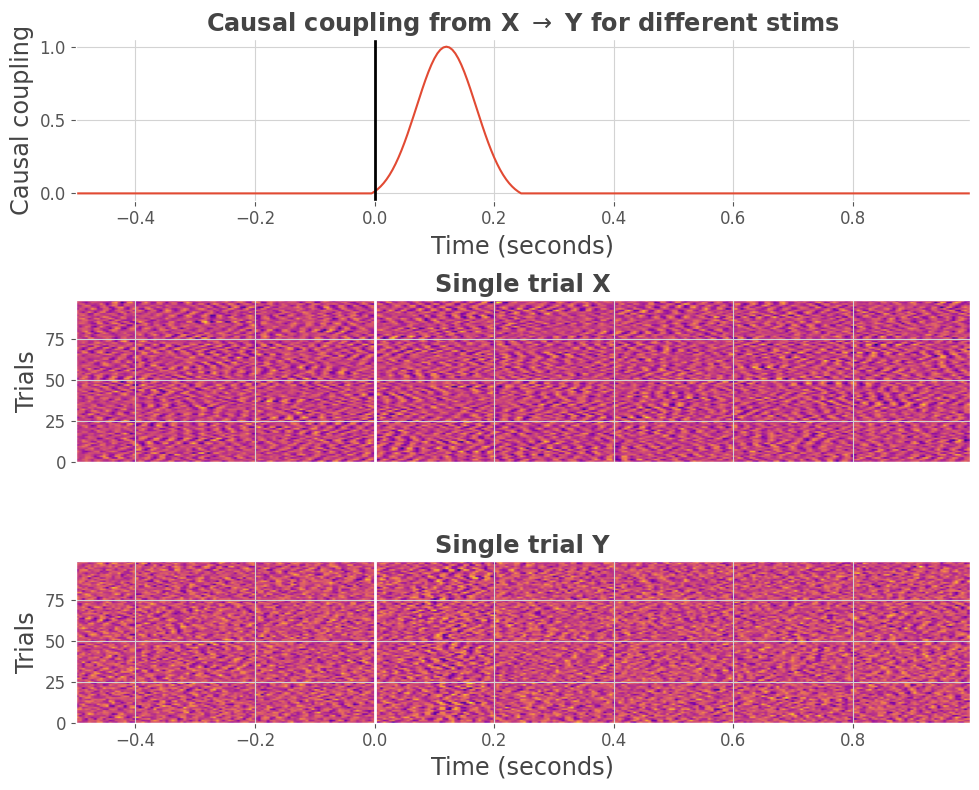

In [2]:
# Parameters
ar_type = 'osc_40'
n_stim = 1
n_epochs = 100

# Simulation
ss = StimSpecAR()
ar_1stim = ss.fit(ar_type=ar_type, n_epochs=n_epochs, n_stim=n_stim, random_state=42)

# Plot single trial data and causal coupling
plt.figure(figsize=(10, 8))
ss.plot()
plt.tight_layout()
plt.show()

### 3c: Three Stimuli Simulation

We simulate 100 trials with three different stimuli.

40Hz oscillations AR model (n_times=300, n_epochs=100, n_stim=3, random_state=42)


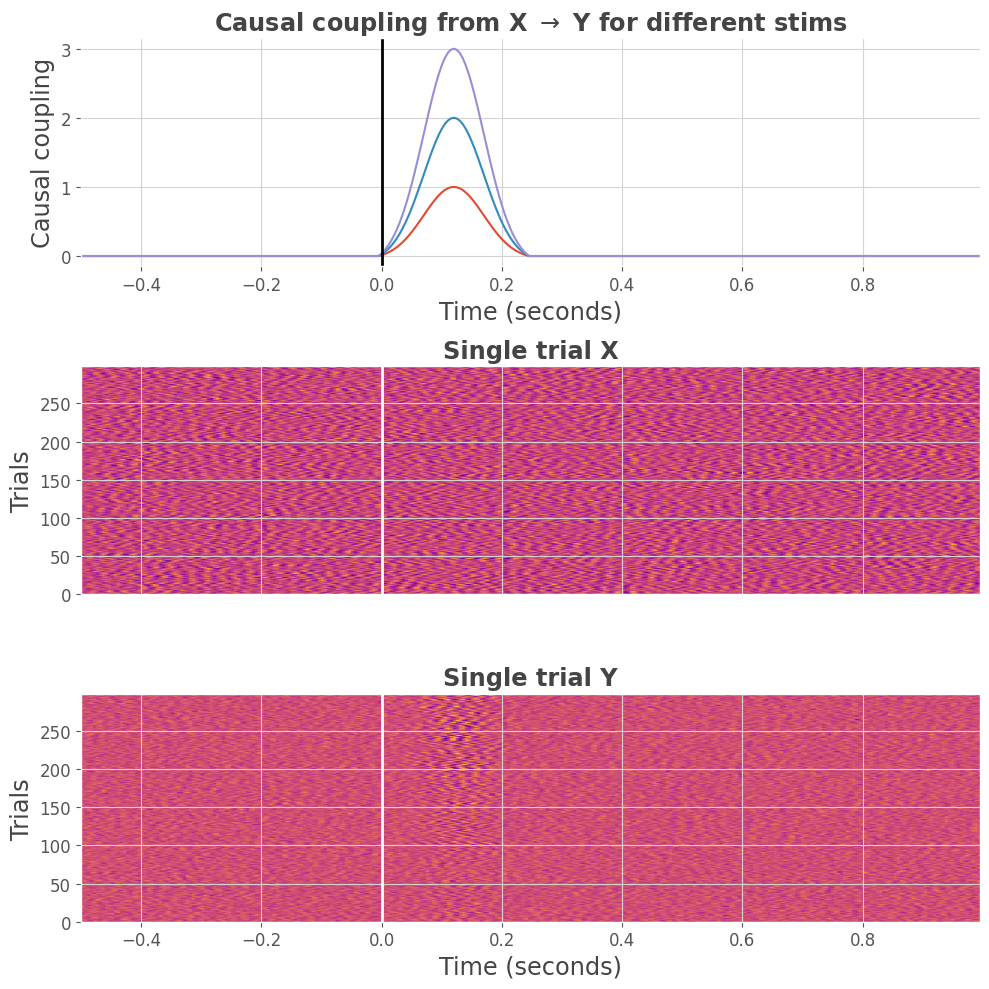

In [3]:
# Parameters
n_stim_3 = 3
n_epochs_3 = 100

# Simulation
ss_3stim = StimSpecAR()
ar_3stim = ss_3stim.fit(ar_type=ar_type, n_epochs=n_epochs_3, n_stim=n_stim_3, random_state=42)

# Plot
plt.figure(figsize=(10, 10))
ss_3stim.plot()
plt.tight_layout()
plt.show()

### 3d: AR Model Equations

Based on the `frites` source code for `osc_40`, the bivariate autoregressive model is defined by:

$$x_t = 0.55 x_{t-1} - 0.8 x_{t-2} + \eta_{1,t}$$
$$y_t = 0.35 y_{t-1} - 0.5 y_{t-2} + c_t (0.5 x_{t-1}) + \eta_{2,t}$$

Where:
- $x_t$ is the source signal.
- $y_t$ is the target signal.
- $\eta_{1,t}, \eta_{2,t}$ are white noise terms.
- $c_t$ is the time-varying causal coupling strength.

## Problem 4: Single-trial time-resolved (dynamic) Functional Connectivity

We use the data simulated in Problem 3b to estimate DFC.

### 4a: DFC Estimation and Averaging

Defining temporal windows (sfreq=199.99999999999983)
    Definition of sliding windows (len=0.75, start=-0.5, stop=0.9950000000000001, step=0.02)
Defining links (n_roi=2; directed=False; net=False, nb_min_links=None)
    Sorting roi names
Gaussian Copula Mutual Information Estimator (mi_type=cc, copnorm=False, biascorrect=False, demeaned=False)
Computing DFC between 1 pairs (gcrn=False)
/home/INT/brovelli.a/code/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| Estimating DFC : 1/1 [00:00<00:00,  215.17it/s]


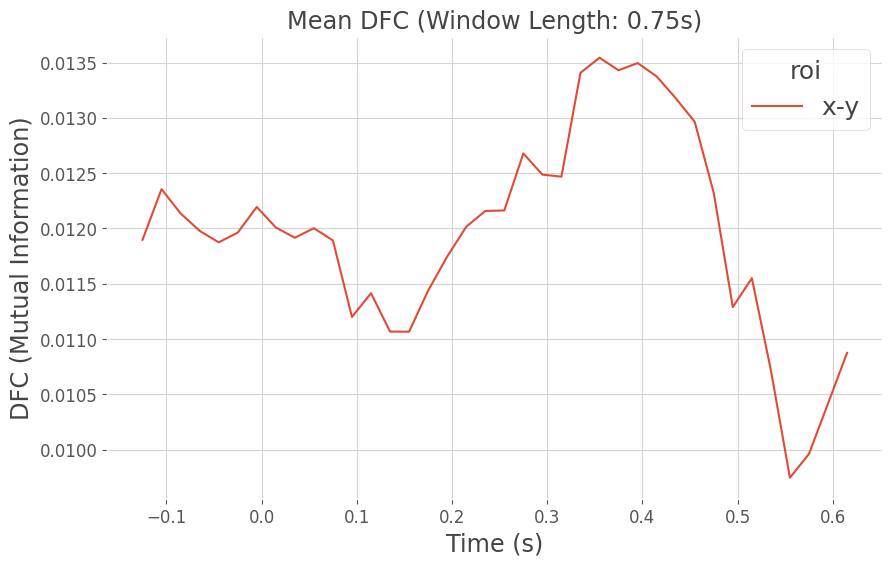

In [4]:
# Data from 3b
data = ar_1stim
times = data.times.data
roi = data.roi.data

# Define sliding windows
# window length = 0.75s, win_step = 0.02s
slwin_len = 0.75
slwin_step = 0.02
win_sample = define_windows(times, slwin_len=slwin_len, slwin_step=slwin_step)[0]
times_p = times[win_sample].mean(1)

# Compute DFC
dfc = conn_dfc(data, win_sample, times=times, roi=roi)

# Plot average time course across trials
plt.figure(figsize=(10, 6))
dfc.mean('trials').plot.line(x='times', hue='roi')
plt.title(f"Mean DFC (Window Length: {slwin_len}s)")
plt.xlabel("Time (s)")
plt.ylabel("DFC (Mutual Information)")
plt.show()

### 4b: Testing Different Window Lengths

Defining temporal windows (sfreq=199.99999999999983)
    Definition of sliding windows (len=0.1, start=-0.5, stop=0.9950000000000001, step=0.02)
Defining links (n_roi=2; directed=False; net=False, nb_min_links=None)
    Sorting roi names
Gaussian Copula Mutual Information Estimator (mi_type=cc, copnorm=False, biascorrect=False, demeaned=False)
Computing DFC between 1 pairs (gcrn=False)
100%|██████████| Estimating DFC : 1/1 [00:00<00:00,  181.30it/s]
Defining temporal windows (sfreq=199.99999999999983)
    Definition of sliding windows (len=0.25, start=-0.5, stop=0.9950000000000001, step=0.02)
Defining links (n_roi=2; directed=False; net=False, nb_min_links=None)
    Sorting roi names
Gaussian Copula Mutual Information Estimator (mi_type=cc, copnorm=False, biascorrect=False, demeaned=False)
Computing DFC between 1 pairs (gcrn=False)
100%|██████████| Estimating DFC : 1/1 [00:00<00:00,  192.36it/s]
Defining temporal windows (sfreq=199.99999999999983)
    Definition of sliding windows (len

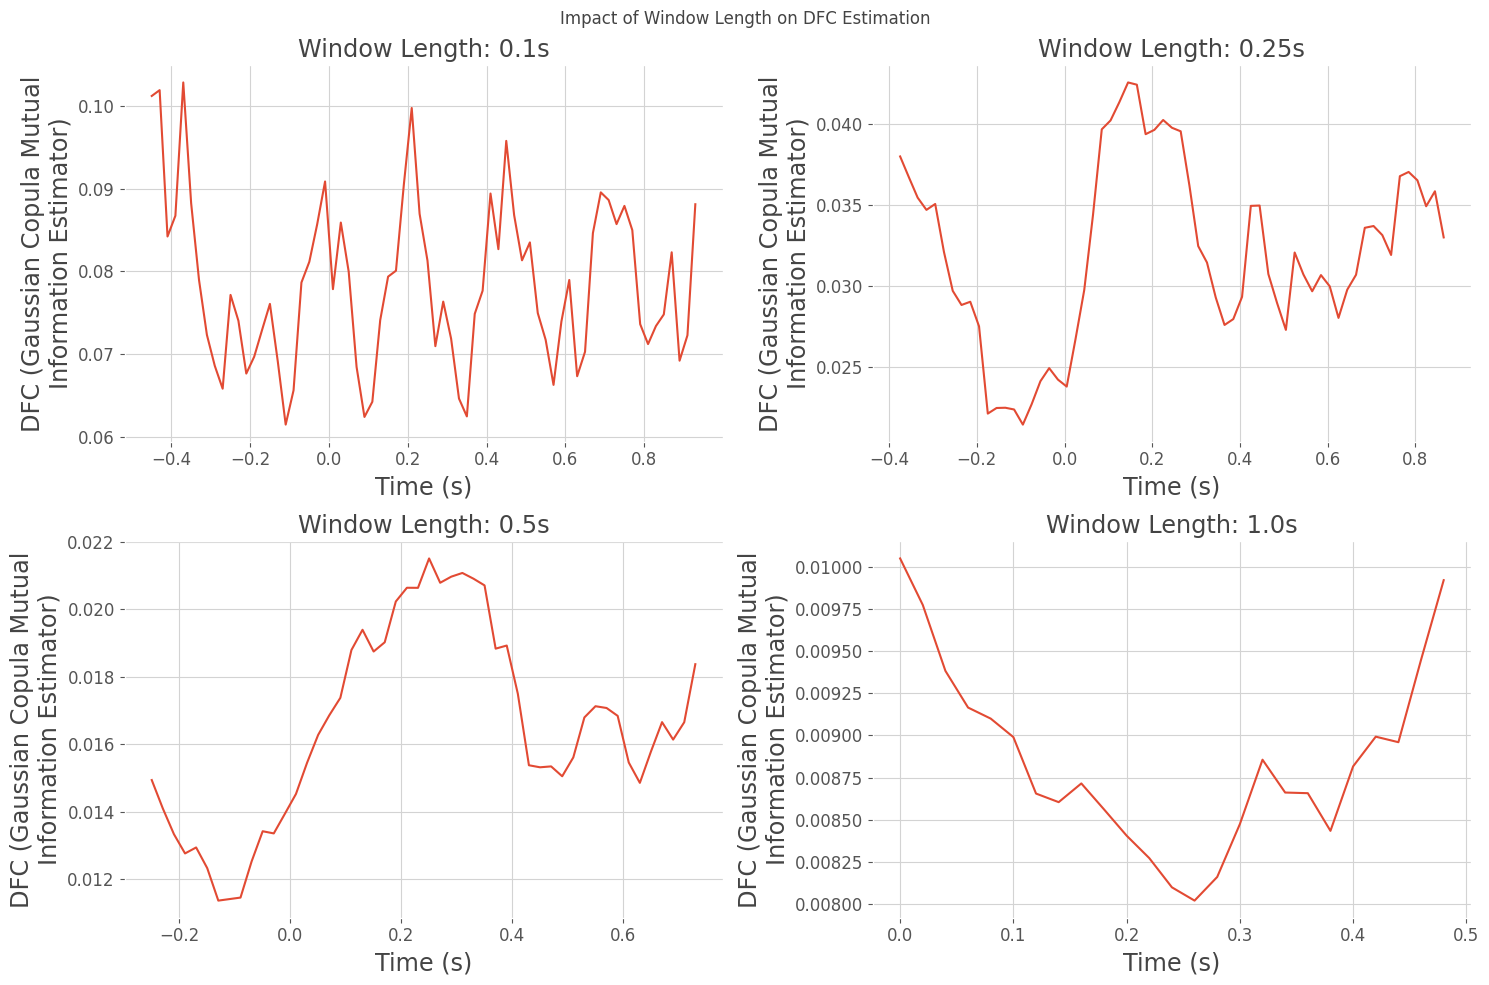

In [5]:
window_lengths = [0.1, 0.25, 0.5, 1.0]

plt.figure(figsize=(15, 10))
for i, win_len in enumerate(window_lengths):
    # Define windows
    win_s = define_windows(times, slwin_len=win_len, slwin_step=slwin_step)[0]
    
    # Compute DFC
    dfc_win = conn_dfc(data, win_s, times=times, roi=roi)
    
    # Plot
    plt.subplot(2, 2, i + 1)
    dfc_win.mean('trials').plot.line(x='times', hue='roi', add_legend=False)
    plt.title(f"Window Length: {win_len}s")
    plt.xlabel("Time (s)")

plt.suptitle("Impact of Window Length on DFC Estimation")
plt.tight_layout()
plt.show()

**Interpretation:**
- **Short windows (e.g., 0.1s):** Provide high temporal resolution but may be noisier as fewer samples are used to estimate the mutual information in each window.
- **Long windows (e.g., 1.0s):** Provide more stable estimates of connectivity but smear out temporal changes, reducing the ability to pinpoint when the coupling occurs.
- The 0.75s window used in 4a provides a balance, capturing the stimulus-induced increase in connectivity between X and Y.